In [1]:
%pip install pyod

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.6/200.6 kB 11.6 MB/s eta 0:00:00


In [2]:
import pyod
import numpy as np
import sklearn
import matplotlib.pyplot as plt

In [3]:
def calculate_anomaly_score(sample, all_hist_info):
    probabilities_for_sample = []

    for hist_info in all_hist_info:
        proj_vec = hist_info['projection_vector']
        bin_edges = hist_info['bin_edges']
        probabilities = hist_info['probabilities']

        projected_value = np.dot(sample, proj_vec)

        bin_idx = np.digitize(projected_value, bin_edges) - 1

        if 0 <= bin_idx < len(probabilities):
            probabilities_for_sample.append(probabilities[bin_idx])
        else:
            probabilities_for_sample.append(0.0)

    if probabilities_for_sample:
        return np.mean(probabilities_for_sample)
    else:
        return 0.0


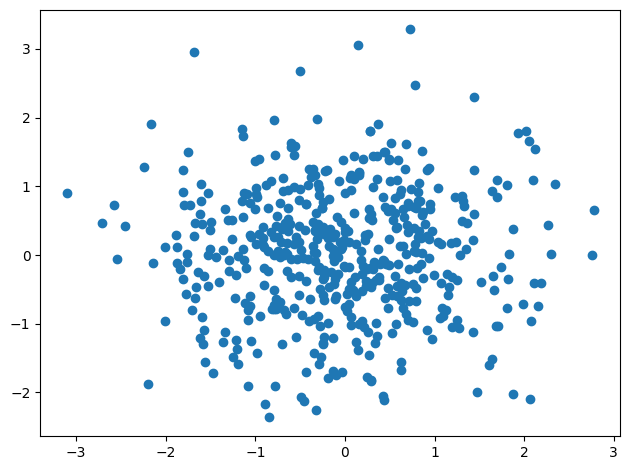

In [4]:
data_blobs, _ = sklearn.datasets.make_blobs(n_samples=500, n_features=2, centers=1, cluster_std=1.0, center_box=(0.0, 0.0))

plt.scatter(data_blobs[:,0], data_blobs[:,1])
plt.tight_layout()
plt.show()

projection_vectors_raw = np.random.multivariate_normal([0, 0], [[1, 0], [0, 1]], size=5)
projection_vectors = projection_vectors_raw / np.linalg.norm(projection_vectors_raw, axis=1)[:, np.newaxis]

all_hist_info = []

for i, proj_vec in enumerate(projection_vectors):
    projected_data = np.dot(data_blobs, proj_vec)

    min_val = np.min(projected_data)
    max_val = np.max(projected_data)
    buffer = (max_val - min_val) * 0.1
    bin_range = (min_val - buffer, max_val + buffer)

    # If you increase the number of bins the anomaly score will get closer and closer to 0
    counts, bin_edges = np.histogram(projected_data, bins=30, range=bin_range)

    probabilities = counts / np.sum(counts)

    all_hist_info.append({
        'projection_vector': proj_vec,
        'bin_edges': bin_edges,
        'counts': counts,
        'probabilities': probabilities
    })


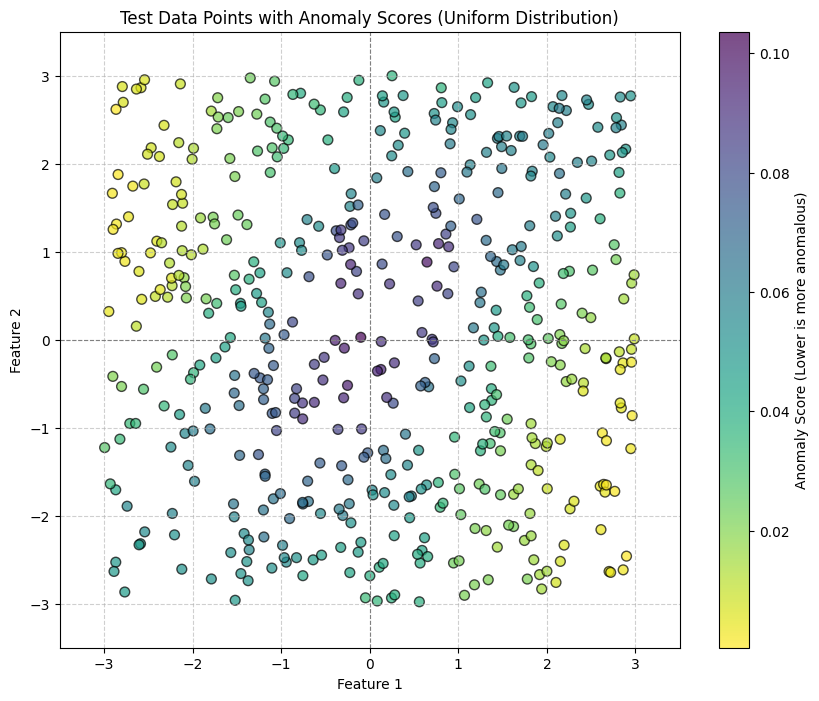

In [5]:
test_data = np.random.uniform(low=-3, high=3, size=(500, 2))

anomaly_scores_test = np.array([calculate_anomaly_score(sample, all_hist_info) for sample in test_data])

plt.figure(figsize=(10, 8))

scatter = plt.scatter(test_data[:, 0], test_data[:, 1], c=anomaly_scores_test, cmap='viridis_r', s=50, alpha=0.7, edgecolor='k')

cbar = plt.colorbar(scatter)
cbar.set_label('Anomaly Score (Lower is more anomalous)')

plt.title('Test Data Points with Anomaly Scores (Uniform Distribution)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlim(-3.5, 3.5)
plt.ylim(-3.5, 3.5)
plt.show()


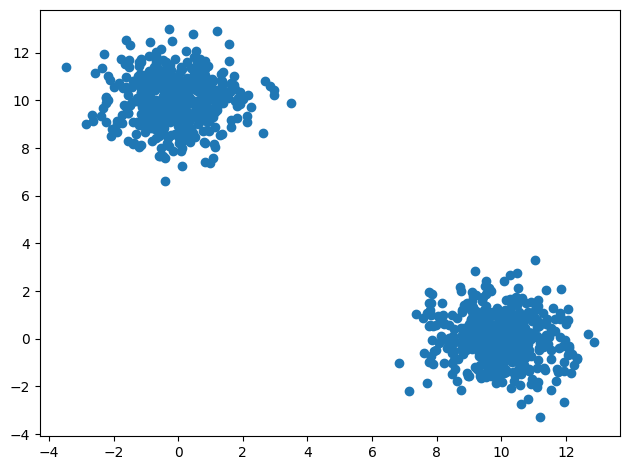

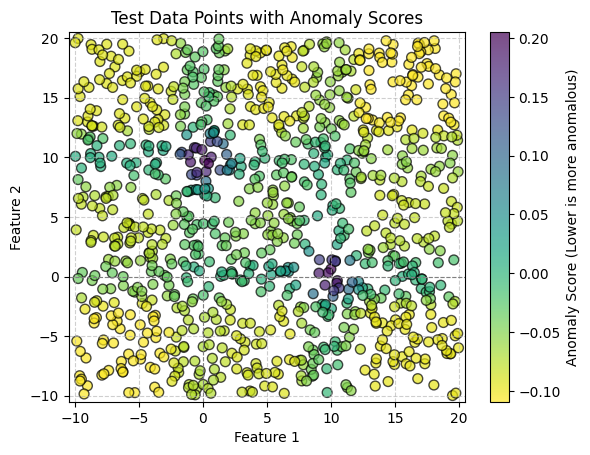

The standard Isolation Forest model creates an anomaly score space distribution that contains a lot of straight edges
This is given because all of the splits are paralel with another axis


In [6]:
from pyod.models.iforest import IsolationForest

data_blobs_2, _ = sklearn.datasets.make_blobs(
    n_samples=1000,
    n_features=2,
    centers=[[10, 0], [0, 10]],
    cluster_std=1.0,
)

plt.scatter(data_blobs_2[:,0], data_blobs_2[:,1])
plt.tight_layout()
plt.show()



clf = IsolationForest(contamination=0.02)
clf.fit(data_blobs_2)

test_data_ex2 = np.random.uniform(low=-10, high=20, size=(1000, 2))
anomaly_scores_ex2 = clf.decision_function(test_data_ex2)

scatter = plt.scatter(test_data_ex2[:, 0], test_data_ex2[:, 1], c=anomaly_scores_ex2, cmap='viridis_r', s=50, alpha=0.7, edgecolor='k')

cbar = plt.colorbar(scatter)
cbar.set_label('Anomaly Score (Lower is more anomalous)')

plt.title('Test Data Points with Anomaly Scores')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlim(-10.5, 20.5)
plt.ylim(-10.5, 20.5)
plt.show()

print("The standard Isolation Forest model creates an anomaly score space distribution that contains a lot of straight edges")
print("This is given because all of the splits are paralel with another axis")

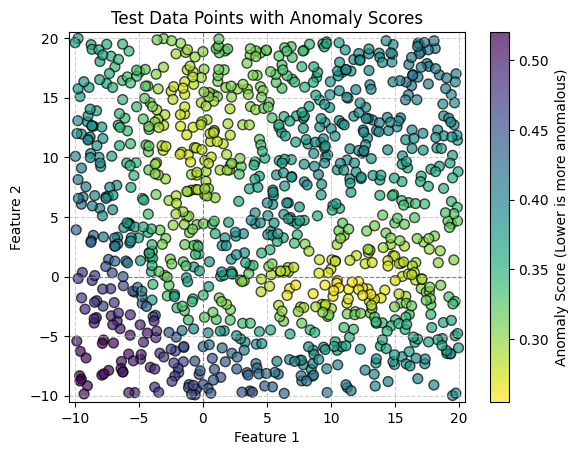

In [7]:
from pyod.models.dif import DIF

dif = DIF(contamination=0.02)
dif.fit(data_blobs_2)

anomaly_scores_dif= dif.decision_function(test_data_ex2)

scatter = plt.scatter(test_data_ex2[:, 0], test_data_ex2[:, 1], c=anomaly_scores_dif, cmap='viridis_r', s=50, alpha=0.7, edgecolor='k')

cbar = plt.colorbar(scatter)
cbar.set_label('Anomaly Score (Lower is more anomalous)')

plt.title('Test Data Points with Anomaly Scores')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlim(-10.5, 20.5)
plt.ylim(-10.5, 20.5)
plt.show()

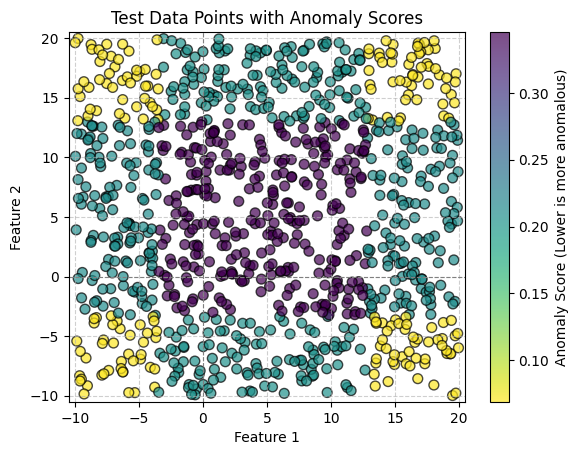

In [8]:
from pyod.models.loda import LODA

loda_clf = LODA(contamination=0.02, n_bins=5000000)
loda_clf.fit(data_blobs_2)

anomaly_scores_loda = loda_clf.decision_function(test_data_ex2)

scatter = plt.scatter(test_data_ex2[:, 0], test_data_ex2[:, 1], c=anomaly_scores_loda, cmap='viridis_r', s=50, alpha=0.7, edgecolor='k')

cbar = plt.colorbar(scatter)
cbar.set_label('Anomaly Score (Lower is more anomalous)')

plt.title('Test Data Points with Anomaly Scores')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlim(-10.5, 20.5)
plt.ylim(-10.5, 20.5)
plt.show()

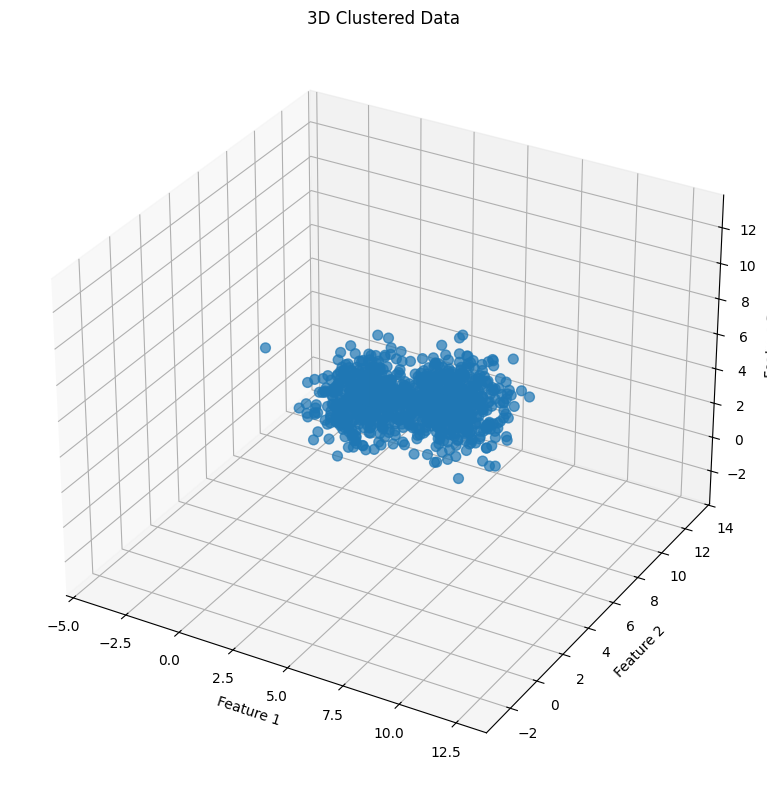

In [9]:
from mpl_toolkits.mplot3d import Axes3D

data_ex3, _ = sklearn.datasets.make_blobs(
    n_samples=1000,
    n_features=3,
    centers=[[0, 10, 0], [10, 0, 10]],
    cluster_std=1.0
)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(data_ex3[:, 0], data_ex3[:, 1], data_ex3[:, 2], s=50, alpha=0.7)

ax.set_title('3D Clustered Data')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Feature 3')

plt.tight_layout()
plt.show()

In [10]:
test_data_3d = np.random.uniform(low=-10, high=20, size=(1000, 3))

In [11]:
iforest_3d = IsolationForest(contamination=0.02)
iforest_3d.fit(data_ex3)

dif_3d = DIF(contamination=0.02)
dif_3d.fit(data_ex3)

loda_3d = LODA(contamination=0.02)
loda_3d.fit(data_ex3)

LODA(contamination=0.02, n_bins=10, n_random_cuts=100)

In [12]:
anomaly_scores_iforest_3d = iforest_3d.decision_function(test_data_3d)
anomaly_scores_dif_3d = dif_3d.decision_function(test_data_3d)
anomaly_scores_loda_3d = loda_3d.decision_function(test_data_3d)

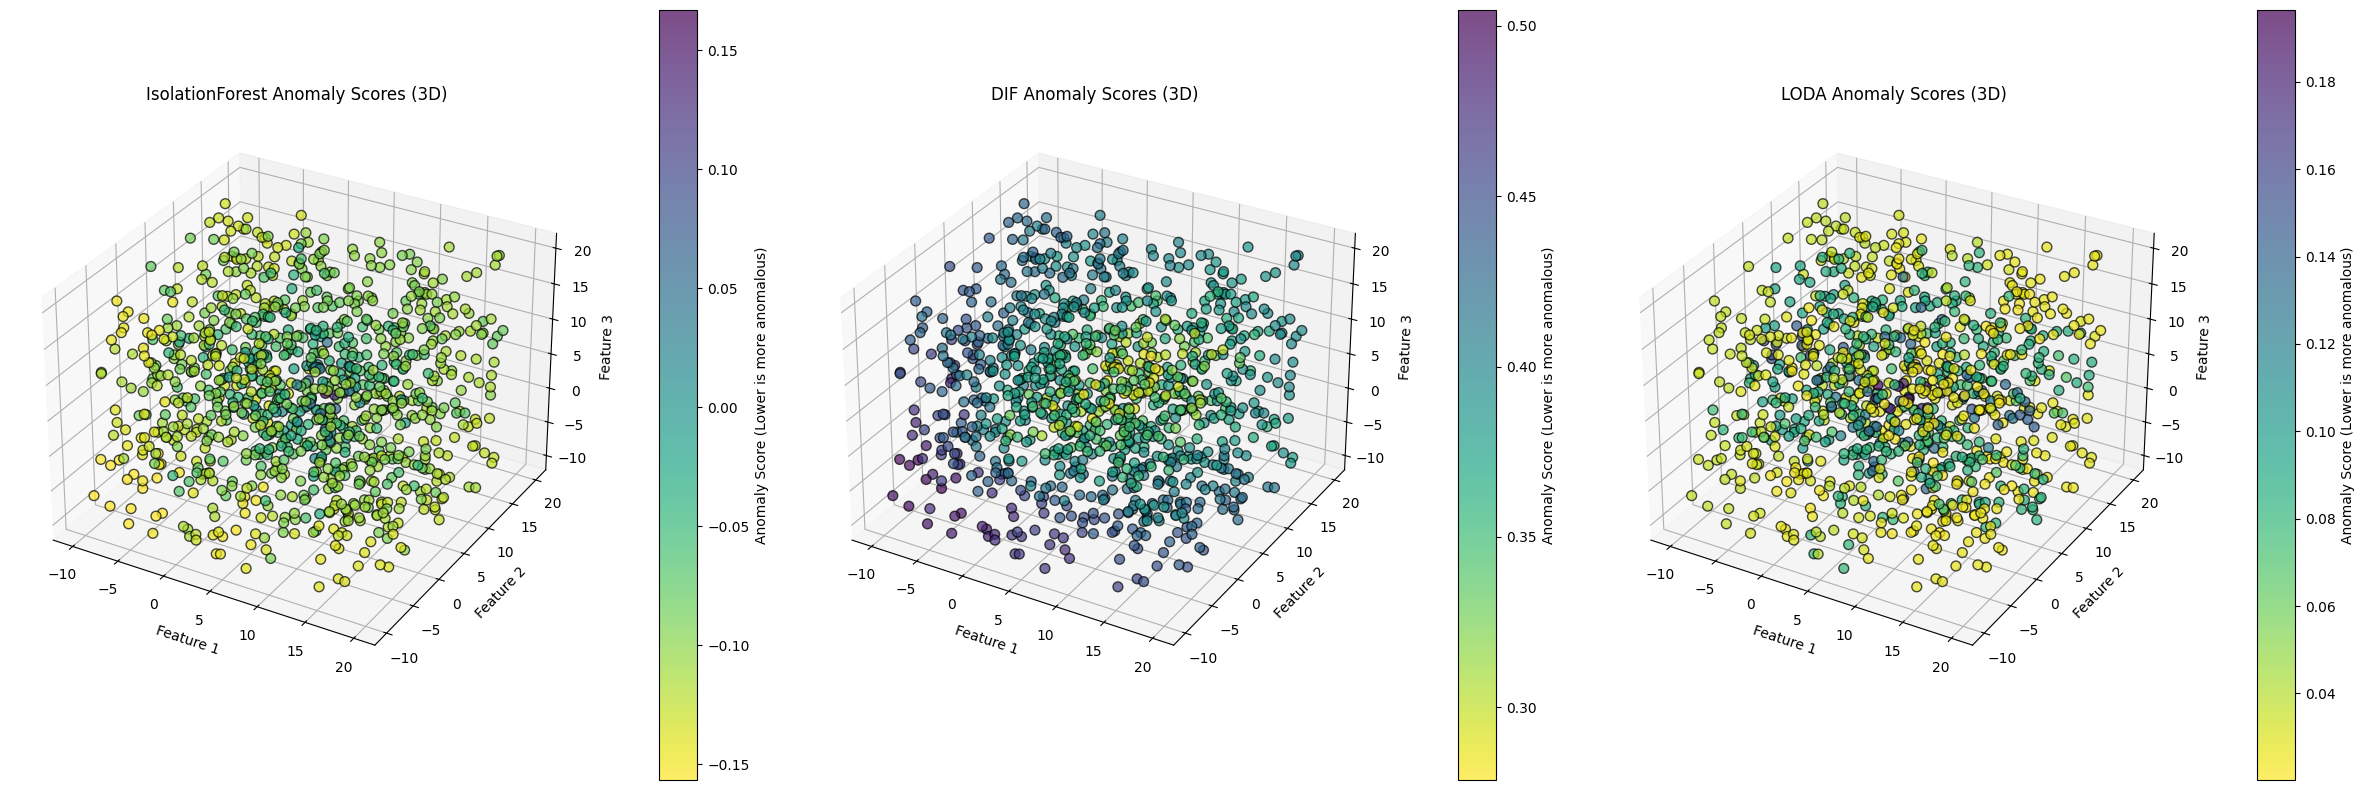

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8), subplot_kw={'projection': '3d'})

scatter1 = axes[0].scatter(test_data_3d[:, 0], test_data_3d[:, 1], test_data_3d[:, 2], c=anomaly_scores_iforest_3d, cmap='viridis_r', s=50, alpha=0.7, edgecolor='k')
cbar1 = fig.colorbar(scatter1, ax=axes[0], pad=0.1)
cbar1.set_label('Anomaly Score (Lower is more anomalous)')
axes[0].set_title('IsolationForest Anomaly Scores (3D)')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].set_zlabel('Feature 3')

scatter2 = axes[1].scatter(test_data_3d[:, 0], test_data_3d[:, 1], test_data_3d[:, 2], c=anomaly_scores_dif_3d, cmap='viridis_r', s=50, alpha=0.7, edgecolor='k')
cbar2 = fig.colorbar(scatter2, ax=axes[1], pad=0.1)
cbar2.set_label('Anomaly Score (Lower is more anomalous)')
axes[1].set_title('DIF Anomaly Scores (3D)')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].set_zlabel('Feature 3')

scatter3 = axes[2].scatter(test_data_3d[:, 0], test_data_3d[:, 1], test_data_3d[:, 2], c=anomaly_scores_loda_3d, cmap='viridis_r', s=50, alpha=0.7, edgecolor='k')
cbar3 = fig.colorbar(scatter3, ax=axes[2], pad=0.1)
cbar3.set_label('Anomaly Score (Lower is more anomalous)')
axes[2].set_title('LODA Anomaly Scores (3D)')
axes[2].set_xlabel('Feature 1')
axes[2].set_ylabel('Feature 2')
axes[2].set_zlabel('Feature 3')

plt.tight_layout()
plt.show()

In [14]:
import scipy.io
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

mat = scipy.io.loadmat('/content/shuttle.mat')

X_train, X_test, y_train, y_test = train_test_split(mat['X'], mat['y'], test_size=0.4)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [15]:
iforest_bal_accuracy_scores = []
iforest_roc_auc_scores = []
dif_bal_accuracy_scores = []
dif_roc_auc_scores = []
loda_bal_accuracy_scores = []
loda_roc_auc_scores = []

In [18]:
from sklearn.metrics import balanced_accuracy_score, roc_auc_score

for i in range(10):
    X_train, X_test, y_train, y_test = train_test_split(mat['X'], mat['y'], test_size=0.4)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    iforest = IsolationForest(contamination=0.02)
    dif = DIF(contamination=0.02)
    loda = LODA(contamination=0.02)

    iforest.fit(X_train_scaled)
    dif.fit(X_train_scaled)
    loda.fit(X_train_scaled)

    iforest_anomaly_scores = iforest.decision_function(X_test_scaled)
    dif_anomaly_scores = dif.decision_function(X_test_scaled)
    loda_anomaly_scores = loda.decision_function(X_test_scaled)

    iforest_predictions = iforest.predict(X_test_scaled)
    dif_predictions = dif.predict(X_test_scaled)
    loda_predictions = loda.predict(X_test_scaled)

    iforest_predictions_mapped = np.where(iforest_predictions == -1, 0, iforest_predictions)
    dif_predictions_mapped = np.where(dif_predictions == -1, 0, dif_predictions)
    loda_predictions_mapped = np.where(loda_predictions == -1, 0, loda_predictions)

    iforest_bal_accuracy_scores.append(balanced_accuracy_score(y_test, iforest_predictions_mapped))
    dif_bal_accuracy_scores.append(balanced_accuracy_score(y_test, dif_predictions_mapped))
    loda_bal_accuracy_scores.append(balanced_accuracy_score(y_test, loda_predictions_mapped))

    iforest_roc_auc_scores.append(roc_auc_score(y_test, iforest_anomaly_scores))
    dif_roc_auc_scores.append(roc_auc_score(y_test, dif_anomaly_scores))
    loda_roc_auc_scores.append(roc_auc_score(y_test, loda_anomaly_scores))

In [20]:
import numpy as np

print(f"IsolationForest - Balanced Accuracy: Mean = {np.mean(iforest_bal_accuracy_scores):.4f}, Std = {np.std(iforest_bal_accuracy_scores):.4f}")
print(f"IsolationForest - ROC AUC: Mean = {np.mean(iforest_roc_auc_scores):.4f}, Std = {np.std(iforest_roc_auc_scores):.4f}")

print(f"DIF - Balanced Accuracy: Mean = {np.mean(dif_bal_accuracy_scores):.4f}, Std = {np.std(dif_bal_accuracy_scores):.4f}")
print(f"DIF - ROC AUC: Mean = {np.mean(dif_roc_auc_scores):.4f}, Std = {np.std(dif_roc_auc_scores):.4f}")

print(f"LODA - Balanced Accuracy: Mean = {np.mean(loda_bal_accuracy_scores):.4f}, Std = {np.std(loda_bal_accuracy_scores):.4f}")
print(f"LODA - ROC AUC: Mean = {np.mean(loda_roc_auc_scores):.4f}, Std = {np.std(loda_roc_auc_scores):.4f}")

IsolationForest - Balanced Accuracy: Mean = 0.3621, Std = 0.0054
IsolationForest - ROC AUC: Mean = 0.0035, Std = 0.0009
DIF - Balanced Accuracy: Mean = 0.5012, Std = 0.0007
DIF - ROC AUC: Mean = 0.9691, Std = 0.0059
LODA - Balanced Accuracy: Mean = 0.5646, Std = 0.0551
LODA - ROC AUC: Mean = 0.5156, Std = 0.2826
